In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, GlobalAveragePooling2D, Dense, Reshape,
                                     Multiply, Flatten, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define dataset paths
dataset_path = "/content/drive/MyDrive/Colab Notebooks/TomatoDataset"  # Change to your dataset path
output_base = "/content/drive/MyDrive/Colab Notebooks/NEWSPLITOMATO"  # Where the split dataset will be stored

train_dir = os.path.join(output_base, "train")
test_dir = os.path.join(output_base, "test")

# Create train and test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get class names
classes = os.listdir(dataset_path)

# Split and copy images
split_ratio = 0.2  # 20% test, 80% train

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    # Ensure it's a valid directory
    if not os.path.isdir(class_path):
        print(f"Skipping {class_name} (Not a directory)")
        continue

    # Debug: Check if folder exists
    if not os.path.exists(class_path):
        print(f"Error: Folder {class_path} does not exist!")
        continue

    # Create class subdirectories in train and test folders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # List all images in class folder (case-insensitive filtering)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    # Debug: Print detected images
    print(f"Class: {class_name}, Found {len(images)} images")

    # Check if images list is empty
    if not images:
        print(f"⚠️ Warning: No images found in {class_path}. Skipping this class.")
        continue

    # Shuffle and split dataset
    train_images, test_images = train_test_split(images, test_size=split_ratio, random_state=42)

    # Copy images to train folder
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_dir, class_name, img)
        shutil.copy2(src, dst)

    # Copy images to test folder
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, class_name, img)
        shutil.copy2(src, dst)

print("✅ Dataset split completed!")

Class: Tomato___Target_Spot, Found 99 images
Class: Tomato___Leaf_Mold, Found 400 images
Class: Tomato___Septoria_leaf_spot, Found 106 images
Class: Tomato___Spider_mites Two-spotted_spider_mite, Found 121 images
Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus, Found 100 images
Class: Tomato___Bacterial_spot, Found 108 images
Class: Tomato___Early_blight, Found 298 images
Class: Tomato___Late_blight, Found 111 images


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-3-3cd65cf84b6b>", line 57, in <cell line: 0>
    shutil.copy2(src, dst)
  File "/usr/lib/python3.11/shutil.py", line 448, in copy2
    copyfile(src, dst, follow_symlinks=follow_symlinks)
  File "/usr/lib/python3.11/shutil.py", line 244, in copyfile
    pass
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.1

TypeError: object of type 'NoneType' has no len()

In [ ]:
# ==========================
# MODEL: CNN with Attention (SE + Spatial + Residual + Transfer Learning)
# ==========================

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Reshape, Multiply, Input, BatchNormalization, Activation, Add
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================
# Squeeze-and-Excitation Block
# ==========================
def se_block(input_tensor, reduction_ratio=16):
    """ Squeeze-and-Excitation Block """
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // reduction_ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

# ==========================
# Spatial Attention Block
# ==========================
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.attention_conv = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, input_tensor):
        avg_pool = tf.reduce_mean(input_tensor, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(input_tensor, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.attention_conv(concat)
        return Multiply()([input_tensor, attention])

# ==========================
# Improved CNN Model with Transfer Learning & Residual Connections
# ==========================
def build_cnn_with_attention(input_shape=(224, 224, 3), num_classes=11):
    """ CNN Model with SE Attention, Spatial Attention, Residual Connections & Transfer Learning """
    inputs = Input(shape=input_shape)

    # Transfer Learning Backbone
    base_model = EfficientNetB0(weights="imagenet", include_top=False, input_tensor=inputs)
    x = base_model.output

    # Residual Block - Adjusted to match the shape of 'x' after Block 1 processing
    res = Conv2D(128, (1, 1), padding='same')(x)
    res = MaxPooling2D((2, 2))(res) # Added MaxPooling2D to downsample to (3,3,128)
    # res = MaxPooling2D((2, 2))(res) # Removed the second MaxPooling2D to avoid further downsampling


    # Block 1
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = se_block(x)
    x = SpatialAttention()(x)
    x = Add()([x, res])  # Residual Connection


    # Block 2 - Reduced MaxPooling2D
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    #x = MaxPooling2D((2, 2))(x) # Removed MaxPooling
    x = se_block(x)
    x = SpatialAttention()(x)

    # Block 3 - Reduced MaxPooling2D
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    #x = MaxPooling2D((2, 2))(x)  #Removed MaxPooling
    x = se_block(x)
    x = SpatialAttention()(x)

    # Fully Connected Layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ==========================
# DATA AUGMENTATION
# ==========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==========================
# TRAINING
# ==========================
NUM_CLASSES = len(train_dataset.class_indices)
cnn_with_attention = build_cnn_with_attention(num_classes=NUM_CLASSES)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    verbose=1
)

print("\nTraining Improved CNN with Attention...")
history = cnn_with_attention.fit(
    train_dataset,
    epochs=50,
    validation_data=test_dataset,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ==========================
# EVALUATION
# ==========================
test_loss, test_accuracy = cnn_with_attention.evaluate(test_dataset)
print(f"🚀 Final Test Accuracy: {test_accuracy * 100:.2f}%")


Found 12804 images belonging to 10 classes.
Found 3207 images belonging to 10 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Improved CNN with Attention...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 432s 806ms/step - accuracy: 0.5705 - loss: 1.2680 - val_accuracy: 0.1883 - val_loss: 2.6027 - learning_rate: 1.0000e-04
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 242s 603ms/step - accuracy: 0.9125 - loss: 0.2668 - val_accuracy: 0.4107 - val_loss: 2.3348 - learning_rate: 1.0000e-04
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 251s 626ms/step - accuracy: 0.9548 - loss: 0.1465 - val_accuracy: 0.2295 - val_loss: 4.7543 - learning_rate: 1.0000e-04
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 239s 596ms/step - accuracy: 0.9564 - loss: 0.1312 - val_accuracy: 0.5426 - val_loss: 2.0228 - learning_rate: 1.0000e-04
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 239s 597ms/step - accuracy: 0.9696 - loss: 0.0897 - val_accuracy: 0.1880 - val_loss: 5.7316 - learning_rate: 1.0000e-04
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 241s 600ms/step - accuracy: 0.9722 - loss: 0.0814 - val_accuracy: 0.1849 - val_loss: 5.3874 - learning_rate: 1.0000e-04
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 

101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step


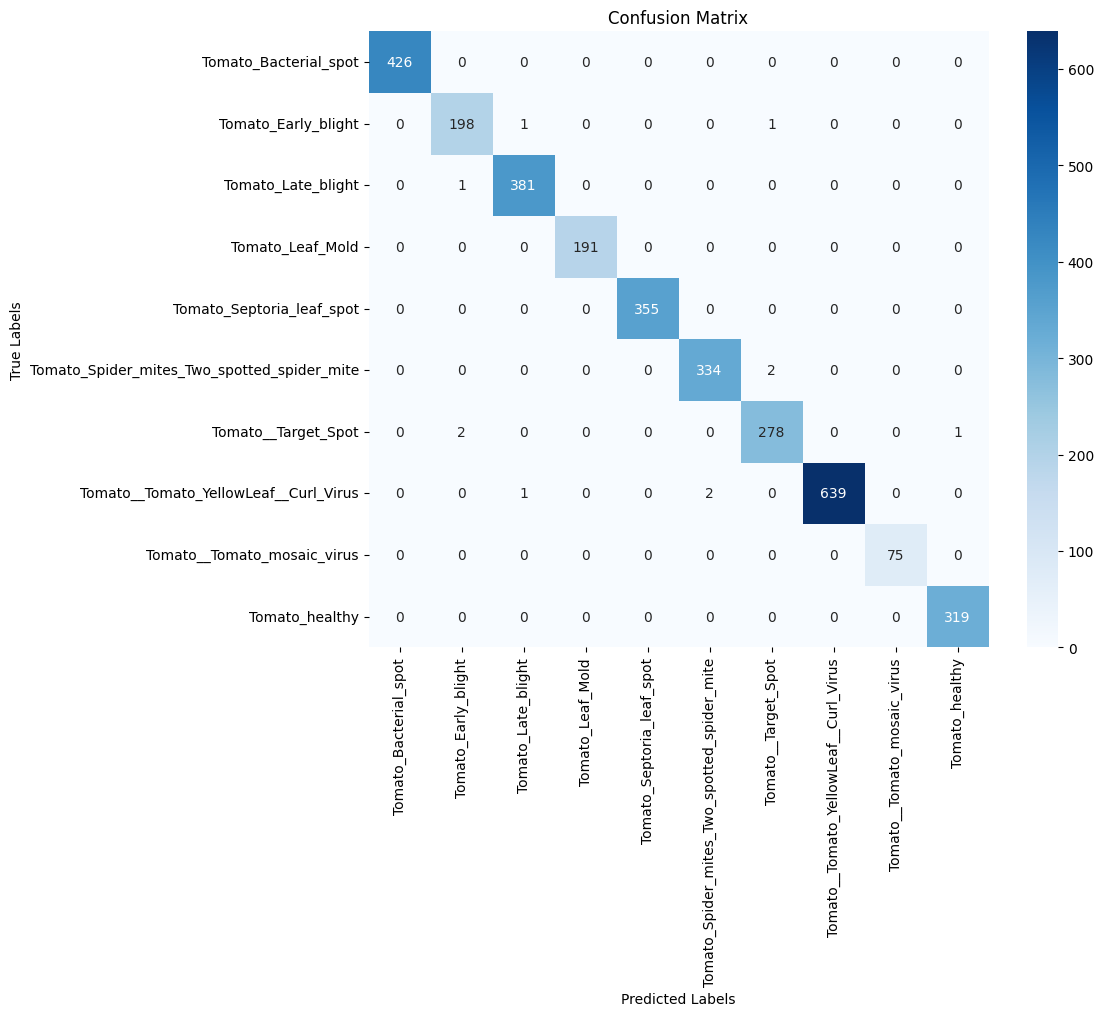

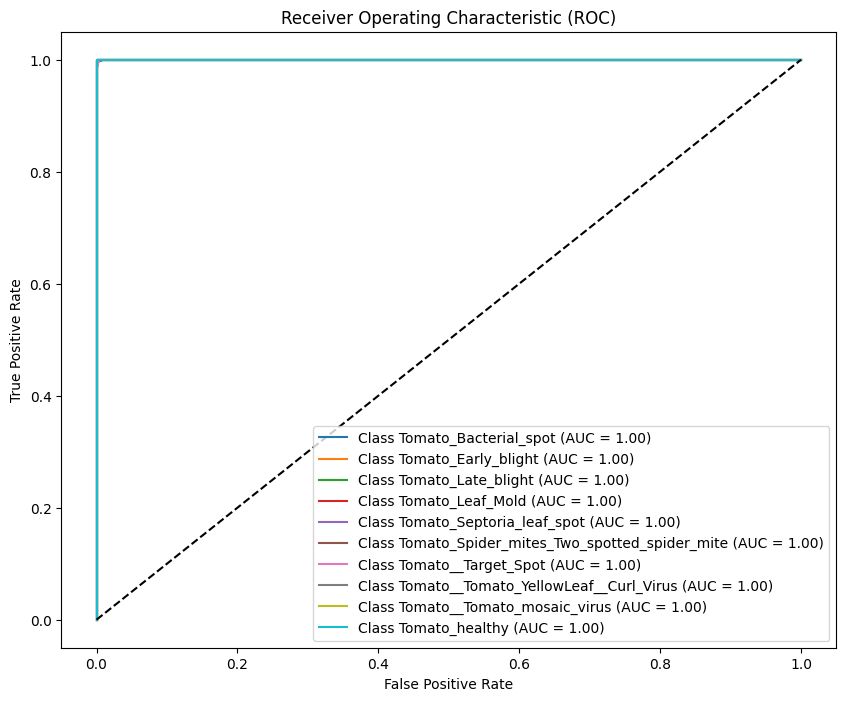

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf # Import tensorflow if not already imported

# ... (your previous code) ...

# Get true labels and predictions
y_true = test_dataset.classes
predictions = cnn_with_attention.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_dataset.class_indices.keys()), yticklabels=list(test_dataset.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# ROC Curve
plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(tf.keras.utils.to_categorical(y_true, NUM_CLASSES)[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {list(test_dataset.class_indices.keys())[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()